In [2]:
from typing import TypedDict, Literal
class protofoliostate(TypedDict):
    amount_usd: float
    total_usd: float
    target_currency: Literal['INR', 'EUR']
    total: float

In [4]:
def calc_total(state: protofoliostate) -> protofoliostate:
    state['total_usd'] = state['amount_usd'] * 1.08  
    return state
def convert_to_inr(state: protofoliostate) -> protofoliostate:
    state['total'] = state['total_usd'] * 85.0  
    return state
def convert_to_eur(state: protofoliostate) -> protofoliostate:
    state['total'] = state['total_usd'] * 0.9  
    return state
def choose_conversion(state: protofoliostate) -> str:
    return state['target_currency']

In [6]:
from langgraph.graph import StateGraph, START, END
builder = StateGraph(protofoliostate)
builder.add_node("calc_total", calc_total)
builder.add_node("convert_to_inr", convert_to_inr)
builder.add_node("convert_to_eur", convert_to_eur)
builder.add_edge(START, "calc_total")
builder.add_conditional_edges("calc_total", choose_conversion, {
    "INR": "convert_to_inr",
    "EUR": "convert_to_eur"
})
builder.add_edge("convert_to_inr", END)
graph = builder.compile()

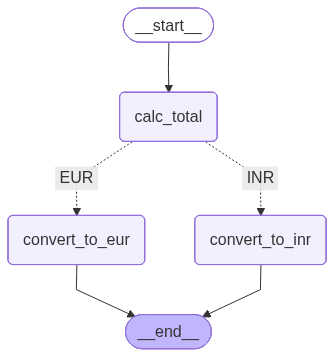

In [7]:
from IPython.display import Image, display
display(Image(graph.get_graph().draw_mermaid_png()))